In [51]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import time
import os
import os
import tensorflow as tf
from tensorflow.keras import mixed_precision
import gc

tf.keras.mixed_precision.set_global_policy('float32')

# Note: Your model will now output float16. 
# Ensure your last layer is float32 for stability:
# self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

# Standard Conda path for libdevice
conda_cuda_path = os.path.join(os.environ.get('CONDA_PREFIX', ''), "Library", "bin")
if os.path.exists(conda_cuda_path):
    os.environ['XLA_FLAGS'] = f"--xla_gpu_cuda_data_dir={conda_cuda_path}"
    print(f"XLA Path set to: {conda_cuda_path}")

# EMERGENCY BYPASS: If it still fails, disable JIT for now. 
# It will be slightly slower, but it will NOT crash.
USE_JIT = False

import os
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir="C:/Users/caspe/anaconda3/envs/SPIKEDETEC/Library/bin"'

XLA Path set to: C:\Users\caspe\anaconda3\envs\SPIKEDETEC\Library\bin


In [52]:
# 1. Load MNIST
(x_all, y_all), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Flatten and Normalize (Standard step)
x_all = x_all.reshape(-1, 784).astype('uint8') / 255.0
x_test = x_test.reshape(-1, 784).astype('uint8') / 255.0

# 3. Create FIXED Permutation (The "p" in pMNIST)
rng = np.random.RandomState(42)
perm = rng.permutation(784)

x_all = x_all[:, perm]
x_test = x_test[:, perm]

# --- NEW: Train/Val Split (90% Train, 10% Val) ---
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_all, y_all, test_size=0.1, random_state=42, stratify=y_all
)

# 4. Reshape to [Batch, Time, Channels] for your RNN
x_train = x_train[:, :, np.newaxis]
x_val   = x_val[:, :, np.newaxis]
x_test  = x_test[:, :, np.newaxis]

# 5. Labels to int32
y_train = y_train.astype('int32')
y_val   = y_val.astype('int32')
y_test  = y_test.astype('int32')

# 6. Build datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(256)
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(256)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(256)

print(f"pMNIST Ready. Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

pMNIST Ready. Train: (54000, 784, 1), Val: (6000, 784, 1), Test: (10000, 784, 1)


##  Global field block

In [53]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import scipy.linalg

# --- 1. THE ODE-BASED BIOLOGICAL PROXY CELL ---
class IsolatedGlobalFieldCell(tf.keras.layers.Layer):
    def __init__(self, units=128, strength=0.1, lambda_slow=0.01, alpha=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units] # [h, G]
        self.strength = strength
        self.lambda_slow = lambda_slow
        self.alpha = alpha

    def build(self, input_shape):
        # Standard initialization - no bias toward rank expansion
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), 
                                    initializer="glorot_uniform", name="w_in")
        self.w_rec = self.add_weight(shape=(self.units, self.units), 
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0), 
                                     name="w_rec")
        self.bias = self.add_weight(shape=(self.units,), 
                                    initializer="zeros", name="bias")

    def call(self, inputs, states):
        prev_h = states[0]
        prev_G = states[1]
        
        # 1. The Raw Global Field (Shifted Cross-Talk)
        # Just simple population feedback.
        half = self.units // 2
        shifted_h = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        
        # ODE update for the field
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * shifted_h
        
        # Field Normalization - CRITICAL to keep the comparison fair 
        # so 'strength' means the same thing across epochs.
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        # 2. Linear Integration
        z_in = tf.matmul(inputs, self.w_in)
        z_rec = tf.matmul(prev_h, self.w_rec)
        
        # 3. MODULATION (The only variable)
        # When strength=0 (Passive), this is exactly 1.0 (No effect)
        field_effect = 1.0 + (self.strength * tf.tanh(G_norm))
        h_candidate = (z_in + z_rec) * field_effect
        
        # 4. Naked Activation
        h_activated = tf.nn.leaky_relu(h_candidate + self.bias, alpha=0.1)
        
        # 5. Temporal Leak (Neurons)
        h = (self.alpha * prev_h) + (1.0 - self.alpha) * h_activated
        
        return h, [h, new_G]

# --- 2. THE HIERARCHICAL NETWORK ---
class HierarchicalGlobalNet(tf.keras.Model):
    def __init__(self, hidden=128, num_classes=10, strength=0.1, lambda_slow=0.01, use_lfp=True):
        super().__init__()
        self.use_lfp = use_lfp
        # We set return_state=True to ensure we can handle the internal states
        self.rnn1 = tf.keras.layers.RNN(
            IsolatedGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow), 
            return_sequences=True
        )
        self.rnn2 = tf.keras.layers.RNN(
            IsolatedGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow), 
            return_sequences=True
        )
        self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

    def call(self, x, training=False):
        # RNN layer returns the sequence directly if return_state=False (default)
        h1_seq = self.rnn1(x, training=training)
        h2_seq = self.rnn2(h1_seq, training=training)
        
        logits = self.out(h2_seq[:, -1, :])
        return logits, h2_seq if self.use_lfp else None

# --- 3. TRAINING & METRICS ---
@tf.function(jit_compile=False)
def train_step(x, y, model, optimizer, loss_fn, train_acc_metric):
    with tf.GradientTape() as tape:
        logits, h_seq = model(x, training=True) 
        loss = loss_fn(y, logits)
        scaled_loss = optimizer.get_scaled_loss(loss)

    h_final = h_seq[:, -1, :] 
    live_var = tf.reduce_mean(tf.math.reduce_std(h_final, axis=-1))

    grads = tape.gradient(scaled_loss, model.trainable_variables)
    if isinstance(optimizer, tf.keras.mixed_precision.LossScaleOptimizer):
        grads = optimizer.get_unscaled_gradients(grads)
    
    grads = [tf.clip_by_norm(g, 1.0) for g in grads]
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    train_acc_metric.update_state(y, logits)
    return loss, live_var

def train_model_tf(model, train_data, val_data, epochs=5, lr=1e-3):
    optimizer = tf.keras.mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=lr))
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    history = {"loss": [], "acc": [], "hidden_metrics": []}

    for epoch in range(epochs):
        train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        pbar = tqdm(train_data, desc=f"Epoch {epoch+1}")
        
        for x_batch, y_batch in pbar:
            loss_val, live_var = train_step(x_batch, y_batch, model, optimizer, loss_fn, train_acc_metric)
            pbar.set_postfix({"loss": f"{loss_val.numpy():.4f}", "acc": f"{train_acc_metric.result().numpy():.4f}", "rank_v": f"{live_var.numpy():.4f}"})

        for x_v, y_v in val_data.take(1):
            logits_v, h_seq_v = model(x_v, training=False)
            metrics = compute_lfp_metrics(h_seq_v.numpy(), strength=model.rnn1.cell.strength)
            val_acc = np.mean(np.argmax(logits_v.numpy(), axis=-1) == y_v.numpy())
            history["loss"].append(loss_val.numpy())
            history["acc"].append(val_acc)
            history["hidden_metrics"].append(metrics)
            
            print(f" [Snapshot] Val_Acc: {val_acc:.4f} | Rank: {metrics['effective_rank']:.2f} | Sync: {metrics['synchrony']:.3f} | Intf: {metrics['interference']:.2f}")
            
    return history

def compute_lfp_metrics(h_seq_np, strength=0.0):
    h_final = np.nan_to_num(h_seq_np[:, -1, :])
    
    # 1. Effective Rank
    s = scipy.linalg.svdvals(h_final)
    p = s / (np.sum(s) + 1e-10)
    eff_rank = np.exp(-np.sum(p * np.log(p + 1e-10)))

    # 2. Synchrony
    corr_matrix = np.nan_to_num(np.corrcoef(h_final.T))
    sync = (np.sum(np.abs(corr_matrix)) - h_final.shape[1]) / (h_final.shape[1]**2 - h_final.shape[1])

    # 3. Autocorrelation (A-Corr)
    h_t, h_prev = h_seq_np[:, 1:, :], h_seq_np[:, :-1, :]
    a_corr = np.mean([np.corrcoef(h_t[0, i], h_prev[0, i])[0, 1] for i in range(min(5, h_t.shape[1]))])

    # 4. Log Interference (Intf)
    modulation_range = np.abs(strength) 
    intf = np.log10(modulation_range + 1e-8)

    # 5. Entropy
    counts, _ = np.histogram(h_final, bins=50)
    probs = counts / (np.sum(counts) + 1e-10)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))

    return {
        "effective_rank": float(eff_rank), "synchrony": float(sync),
        "entropy": float(entropy), "a_corr": float(np.nan_to_num(a_corr)),
        "interference": float(intf)
    }



## Probing

In [54]:
class ProbingGlobalFieldCell(tf.keras.layers.Layer):
    def __init__(self, units=128, strength=0.1, lambda_slow=0.01, mode="modulate", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units]
        self.strength = strength
        self.lambda_slow = lambda_slow
        self.mode = mode # "probe" or "modulate"

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform")
        self.w_rec = self.add_weight(shape=(self.units, self.units), 
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0))
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs, states):
        prev_h, prev_G = states
        
        # 1. Field Update (The Probe)
        half = self.units // 2
        shifted_h = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        obs_h = tf.stop_gradient(shifted_h)
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * obs_h
        
        # 2. Normalization (Always run to keep metrics consistent)
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        # 3. Decision Point: Decouple vs Modulate
        if self.mode == "probe":
            field_effect = 1.0  # Decoupled: Observe only
        else:
            field_effect = 1.0 + (self.strength * tf.tanh(G_norm)) # Modulatory
            
        # 4. Neural Update
        z = tf.matmul(inputs, self.w_in) + tf.matmul(prev_h, self.w_rec) + self.bias
        h_activated = tf.nn.leaky_relu(z * field_effect, alpha=0.1)
        h = (0.3 * prev_h) + (0.7 * h_activated)
        
        return h, [h, new_G]

# --- THE UPDATED CELL ---
class ProbingGlobalFieldCell(tf.keras.layers.Layer):
    def __init__(self, units=128, strength=0.1, lambda_slow=0.01, mode="modulate", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units]
        self.strength = strength
        self.lambda_slow = lambda_slow
        self.mode = mode # "probe" or "modulate"

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform")
        self.w_rec = self.add_weight(shape=(self.units, self.units), 
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0))
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs, states):
        prev_h, prev_G = states
        
        # 1. Field Update (The Probe - always happens)
        half = self.units // 2
        shifted_h = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * shifted_h
        
        # 2. Normalization
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        # 3. Decision Point: Decouple (Probe) vs Modulate
        # If probing, the field exists but the multiplier is invisible to the neuron
        if self.mode == "probe":
            field_effect = 1.0  
        else:
            field_effect = 1.0 + (self.strength * tf.tanh(G_norm))
            
        # 4. Neural Update
        z = tf.matmul(inputs, self.w_in) + tf.matmul(prev_h, self.w_rec) + self.bias
        h_candidate = z * field_effect
        h_activated = tf.nn.leaky_relu(h_candidate, alpha=0.1)
        
        # Standard Leaky Integration
        h = (0.3 * prev_h) + (0.7 * h_activated)
        
        return h, [h, new_G]

# --- THE UPDATED WRAPPER ---
class HierarchicalGlobalNet(tf.keras.Model):
    def __init__(self, hidden=128, num_classes=10, strength=0.1, lambda_slow=0.01, mode="modulate", use_lfp=True):
        super().__init__()
        self.use_lfp = use_lfp
        # PASSING MODE DOWN TO THE CELL
        self.rnn1 = tf.keras.layers.RNN(
            ProbingGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow, mode=mode), 
            return_sequences=True
        )
        self.rnn2 = tf.keras.layers.RNN(
            ProbingGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow, mode=mode), 
            return_sequences=True
        )
        self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

    def call(self, x, training=False):
        h1_seq = self.rnn1(x, training=training)
        h2_seq = self.rnn2(h1_seq, training=training)
        logits = self.out(h2_seq[:, -1, :])
        return logits, h2_seq if self.use_lfp else None
    
def compute_lfp_metrics(h_seq_np, strength=0.0):
    h_final = np.nan_to_num(h_seq_np[:, -1, :])
    
    # 1. Effective Rank
    s = scipy.linalg.svdvals(h_final)
    p = s / (np.sum(s) + 1e-10)
    eff_rank = np.exp(-np.sum(p * np.log(p + 1e-10)))

    # 2. Synchrony
    corr_matrix = np.nan_to_num(np.corrcoef(h_final.T))
    sync = (np.sum(np.abs(corr_matrix)) - h_final.shape[1]) / (h_final.shape[1]**2 - h_final.shape[1])

    # 3. Autocorrelation (A-Corr)
    h_t, h_prev = h_seq_np[:, 1:, :], h_seq_np[:, :-1, :]
    a_corr = np.mean([np.corrcoef(h_t[0, i], h_prev[0, i])[0, 1] for i in range(min(5, h_t.shape[1]))])

    # 4. Log Interference (Intf)
    modulation_range = np.abs(strength) 
    intf = np.log10(modulation_range + 1e-8)

    # 5. Entropy
    counts, _ = np.histogram(h_final, bins=50)
    probs = counts / (np.sum(counts) + 1e-10)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))

    return {
        "effective_rank": float(eff_rank), "synchrony": float(sync),
        "entropy": float(entropy), "a_corr": float(np.nan_to_num(a_corr)),
        "interference": float(intf)
    }

In [ ]:
DATA_PERCENT = 1  
BATCH_SIZE = 128     
EPOCHS = 12
HIDDEN = 16
STRENGTH = -0.04

num_train = int(len(x_train) * DATA_PERCENT)
num_val   = int(len(x_val) * DATA_PERCENT)
num_test  = int(len(x_test) * DATA_PERCENT)

train_ds_subset = tf.data.Dataset.from_tensor_slices((x_train[:num_train], y_train[:num_train])) \
    .shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_subset = tf.data.Dataset.from_tensor_slices((x_val[:num_val], y_val[:num_val])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_subset = tf.data.Dataset.from_tensor_slices((x_test[:num_test], y_test[:num_test])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Test Run Ready: Samples -> Train: {num_train}, Val: {num_val}")

def print_history_summary(history, model, model_name="Model", test_acc=None, data_percent=DATA_PERCENT):
    total_params = model.count_params()
    
    # REACHING INTO THE CELL FOR THE REAL STRENGTH
    try:
        # Check rnn1 -> layer -> cell
        cell = model.rnn1.cell
        # If it's a standard RNN wrapper, we need to check if it's the layer property
        if hasattr(cell, 'layers'): 
             target_cell = cell.layers[0]
        else:
             target_cell = cell
             
        hidden_size = target_cell.units
        field_w = target_cell.strength
        l_slow = target_cell.lambda_slow
    except Exception as e:
        # Fallback if the path above is slightly different in your env
        hidden_size = "N/A"
        field_w = 0.0
        l_slow = 0.0

    print(f"\n{'='*140}")
    print(f" DATA LOG: {model_name}")
    # Included DATA_PERCENT here
    print(f" CONFIG: Hidden: {hidden_size} | Params: {total_params:,} | Field Weight: {field_w:.4f} | Lambda Slow (τ): {l_slow:.4f} | Data: {data_percent*100:.1f}%")
    print(f"{'='*140}")
    
    # 2. Table Headers
    header = f"{'Epoch':<6} | {'Loss':<7} | {'Val-Acc%':<8} | {'Rank':<6} | {'Sync':<6} | {'Entrp':<6} | {'A-Corr':<7} | {'Intf':<6} | {'F-Wgt':<6}"
    print(header)
    print(f"{'-'*140}")

    # 3. Epoch-by-Epoch Data
    for i in range(len(history['loss'])):
        loss = history['loss'][i]
        acc  = history['acc'][i] 
        
        dyn = history['hidden_metrics'][i]
        rank     = dyn.get('effective_rank', 0)
        sync     = dyn.get('synchrony', 0)
        entropy  = dyn.get('entropy', 0)
        autocorr = dyn.get('a_corr', 0)
        interf   = dyn.get('interference', 0)
        
        current_f_wgt = history.get('field_weights', [field_w]*len(history['loss']))[i]

        print(f"{i+1:<6} | {loss:<7.3f} | {acc*100:<8.2f} | {rank:<6.2f} | {sync:<6.3f} | {entropy:<6.2f} | {autocorr:<7.3f} | {interf:<6.3f} | {current_f_wgt:<6.3f}")
    
    # 4. Final Conclusion Block
    final_val_acc = history['acc'][-1] * 100
    test_str = f"{test_acc*100:.2f}%" if test_acc is not None else "N/A"
    
    print(f"{'-'*140}")
    print(f" FINAL PERFORMANCE: Validation Acc: {final_val_acc:.2f}% | TEST ACCURACY: {test_str}")
    print(f" FINAL DYNAMICS   : Rank: {rank:.2f} | Entropy: {entropy:.2f} | Synchrony: {sync:.3f}")
    print(f"{'='*140}\n")


# --- 2. THE UPDATED TRAIN_MODEL_TF FUNCTION ---
def train_model_tf(model, train_data, val_data, epochs=2, lr=1e-3):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    
    @tf.function(jit_compile=False)
    def local_train_step(x, y):
        with tf.GradientTape() as tape:
            logits, h_seq = model(x, training=True)
            loss = loss_fn(y, logits)

        # Calculate live rank proxy for the tqdm bar
        h_final = h_seq[:, -1, :]
        live_var = tf.reduce_mean(tf.math.reduce_std(h_final, axis=-1))

        grads = tape.gradient(loss, model.trainable_variables)
        grads = [tf.clip_by_norm(g, 1.0) for g in grads]
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        
        # RETURNS 3 VALUES
        return loss, logits, live_var

    # 1. Warm-up (Fixed unpacking)
    print("Initializing Model...")
    for x_init, y_init in train_data.take(1):
        _, _, _ = local_train_step(x_init[:1], y_init[:1])
    
    history = {"loss": [], "acc": [], "hidden_metrics": []}
    
    # 2. Training Loop
    for epoch in range(epochs):
        train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        pbar = tqdm(train_data, desc=f"Epoch {epoch+1}")
        
        for x_batch, y_batch in pbar:
            
            loss_val, logits, var_val = local_train_step(x_batch, y_batch)
            
            train_acc_metric.update_state(y_batch, logits)
            
            # Update TQDM with the live rank variance
            pbar.set_postfix({
                "loss": f"{loss_val.numpy():.4f}", 
                "acc": f"{train_acc_metric.result().numpy():.4f}",
                "rank_v": f"{var_val.numpy():.4f}"
            })

        # 3. Validation Snapshot
        for x_v, y_v in val_data.take(1):
            logits_v, h_seq_v = model(x_v, training=False)
            current_strength = getattr(model.rnn1.cell, 'strength', 0.0)
            metrics = compute_lfp_metrics(h_seq_v.numpy(), strength=current_strength)
            val_acc = np.mean(np.argmax(logits_v.numpy(), axis=-1) == y_v.numpy())
            
            history["loss"].append(loss_val.numpy())
            history["acc"].append(val_acc)
            history["hidden_metrics"].append(metrics)
            
            print(f" [Snapshot] Val_Acc: {val_acc:.4f} | Rank: {metrics['effective_rank']:.2f} | Sync: {metrics['synchrony']:.3f}")
            
    return history

def get_recurrent_weights(rnn_layer):
    """Safely finds the recurrent weight matrix in a custom cell."""
    for attr in ['w_rec', 'recurrent_kernel']:
        if hasattr(rnn_layer.cell, attr):
            return getattr(rnn_layer.cell, attr)
    for w in rnn_layer.cell.weights:
        if len(w.shape) == 2 and w.shape[0] == w.shape[1]:
            return w
    return rnn_layer.cell.weights[1]

# --- PHASE 1: THE PROBE (Decoupled) ---
print("\n[Phase 1] Probing GF Dynamics...")
model_probe = HierarchicalGlobalNet(hidden=HIDDEN, strength=STRENGTH, mode="probe") 
_ = model_probe(tf.zeros((1, 784, 1)))

p_init_w1 = get_recurrent_weights(model_probe.rnn1).numpy().copy()
p_init_w2 = get_recurrent_weights(model_probe.rnn2).numpy().copy()

history_probe = train_model_tf(model_probe, train_ds_subset, val_ds_subset, epochs=EPOCHS)

shift_probe = [
    np.linalg.norm(get_recurrent_weights(model_probe.rnn1).numpy() - p_init_w1),
    np.linalg.norm(get_recurrent_weights(model_probe.rnn2).numpy() - p_init_w2)
]

tf.keras.backend.clear_session()
gc.collect()

# --- PHASE 2: THE PASSIVE BASELINE (Strength = 0) ---
print("\n[Phase 2] Training Passive Baseline...")
model_passive = HierarchicalGlobalNet(hidden=HIDDEN, strength=0.0, mode="modulate") 
_ = model_passive(tf.zeros((1, 784, 1)))

b_init_w1 = get_recurrent_weights(model_passive.rnn1).numpy().copy()
b_init_w2 = get_recurrent_weights(model_passive.rnn2).numpy().copy()

history_base = train_model_tf(model_passive, train_ds_subset, val_ds_subset, epochs=EPOCHS)

shift_passive = [
    np.linalg.norm(get_recurrent_weights(model_passive.rnn1).numpy() - b_init_w1),
    np.linalg.norm(get_recurrent_weights(model_passive.rnn2).numpy() - b_init_w2)
]

tf.keras.backend.clear_session()
gc.collect()

# --- PHASE 3: THE ACTIVE MODULATOR (Strength = -0.1) ---
print("\n[Phase 3] Activating GF Modulator...")
model_active = HierarchicalGlobalNet(hidden=HIDDEN, strength=STRENGTH, mode="modulate")
_ = model_active(tf.zeros((1, 784, 1)))

a_init_w1 = get_recurrent_weights(model_active.rnn1).numpy().copy()
a_init_w2 = get_recurrent_weights(model_active.rnn2).numpy().copy()

history_active = train_model_tf(model_active, train_ds_subset, val_ds_subset, epochs=EPOCHS)

shift_active = [
    np.linalg.norm(get_recurrent_weights(model_active.rnn1).numpy() - a_init_w1),
    np.linalg.norm(get_recurrent_weights(model_active.rnn2).numpy() - a_init_w2)
]

# 1. Evaluate models on the actual Test Set
print("Final Evaluation on Test Set...")
test_acc_probe = np.mean([np.mean(np.argmax(model_probe(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
test_acc_passive = np.mean([np.mean(np.argmax(model_passive(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
test_acc_active = np.mean([np.mean(np.argmax(model_active(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])


# --- Summary Comparison ---
print_history_summary(history_probe, model_probe, "PROBE (DECOUPLED)", test_acc=test_acc_probe)
print_history_summary(history_base, model_passive, "PASSIVE BASELINE",test_acc=test_acc_passive)
print_history_summary(history_active, model_active, "ACTIVE MODULATOR",test_acc=test_acc_active)

Test Run Ready: Samples -> Train: 54000, Val: 6000

[Phase 1] Probing GF Dynamics...
Initializing Model...


Epoch 1: 100%|██████████| 422/422 [06:32<00:00,  1.07it/s, loss=2.0056, acc=0.2237, rank_v=1.0621]   


 [Snapshot] Val_Acc: 0.2969 | Rank: 2.54 | Sync: 0.838


Epoch 2: 100%|██████████| 422/422 [06:18<00:00,  1.12it/s, loss=1.8002, acc=0.2884, rank_v=0.7057]     


 [Snapshot] Val_Acc: 0.3438 | Rank: 6.17 | Sync: 0.448


...

Epoch 12: 100%|██████████| 422/422 [06:19<00:00,  1.11it/s, loss=1.5481, acc=0.4483, rank_v=4.4917]     


 [Snapshot] Val_Acc: 0.4688 | Rank: 1.87 | Sync: 0.777

[Phase 2] Training Passive Baseline...
Initializing Model...


Epoch 1: 100%|██████████| 422/422 [10:09<00:00,  1.44s/it, loss=1.8397, acc=0.2452, rank_v=1.1208]


 [Snapshot] Val_Acc: 0.3438 | Rank: 4.40 | Sync: 0.514


Epoch 2:  97%|█████████▋| 409/422 [09:47<00:23,  1.80s/it, loss=1.6794, acc=0.3652, rank_v=1.5761]

## Visualizing metrics


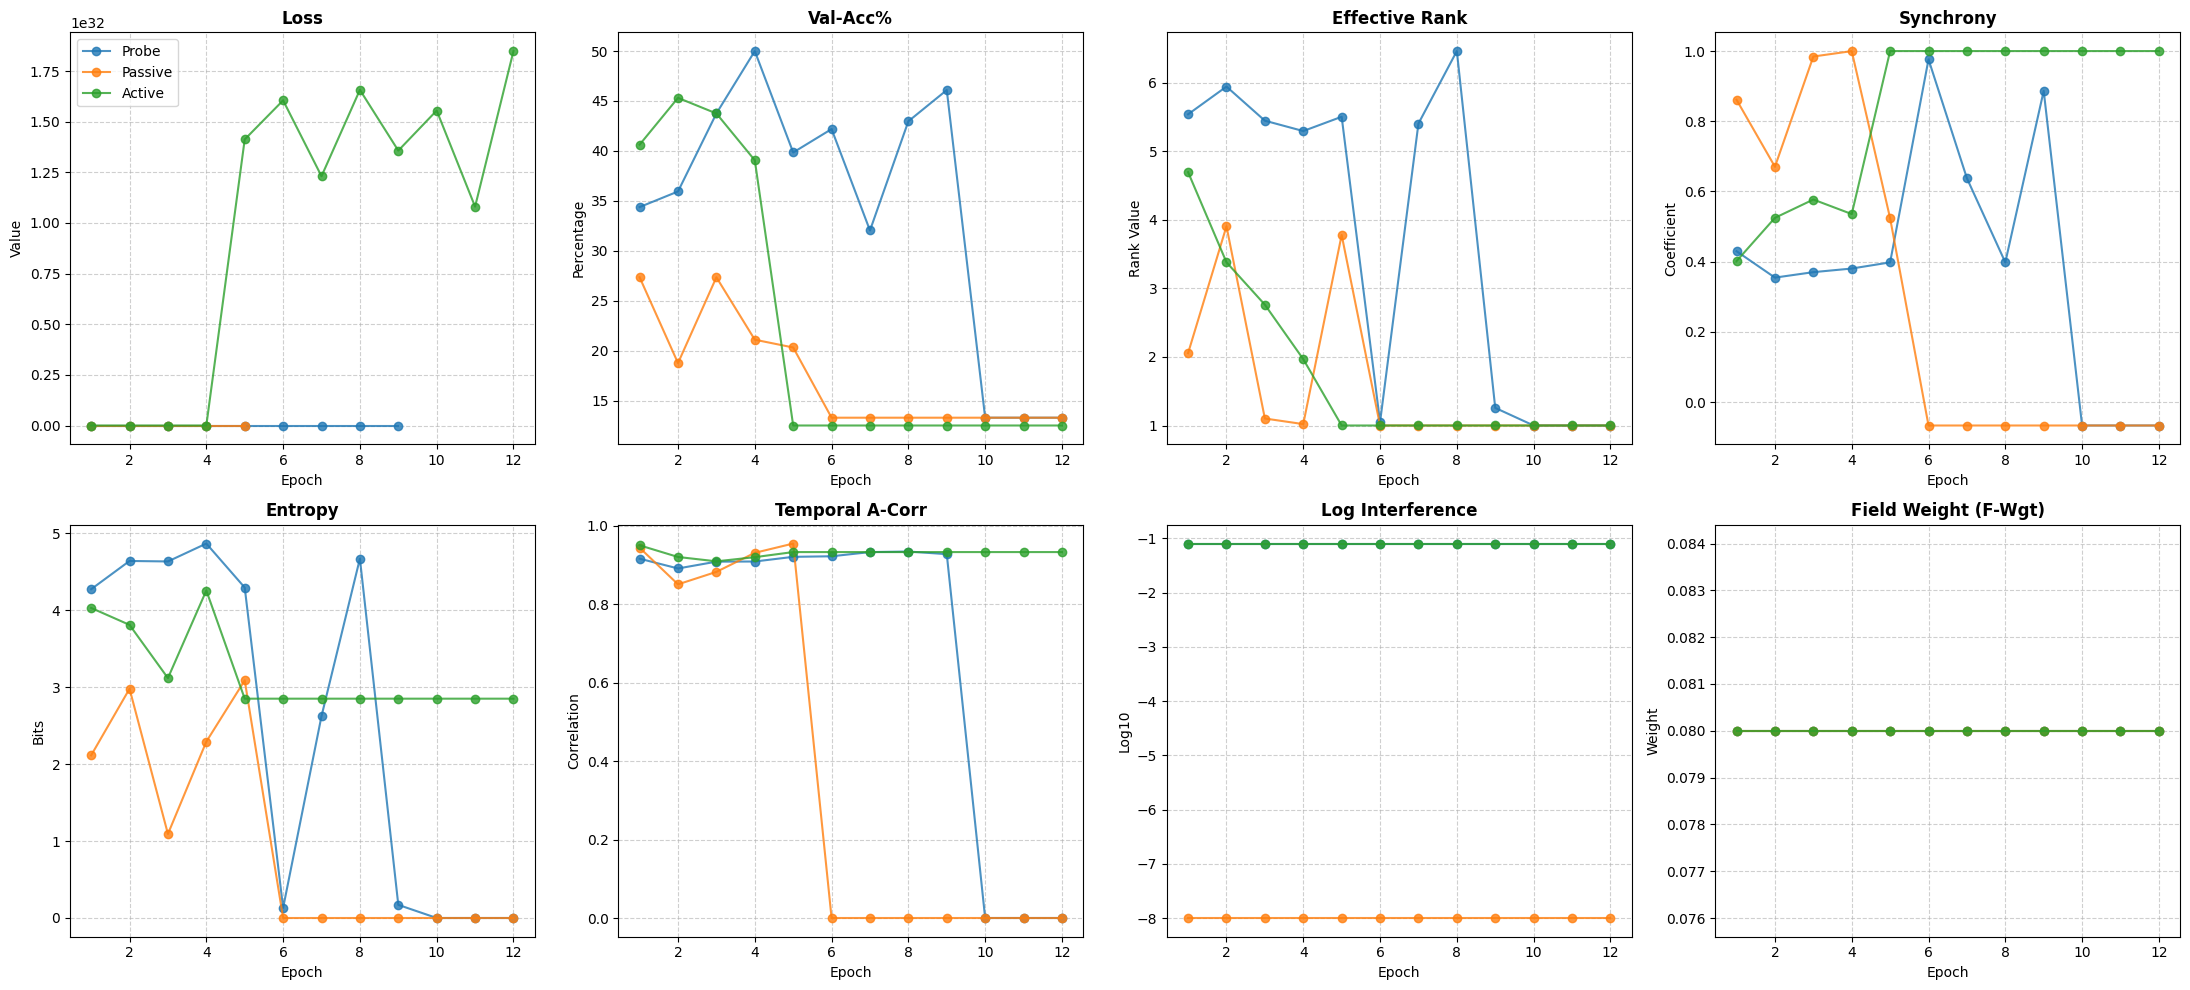

In [ ]:
import matplotlib.pyplot as plt

def plot_full_gf_benchmarks(histories, names=['Probe', 'Passive', 'Active']):
    epochs = range(1, len(histories[0]['loss']) + 1)
    # 2 rows, 4 columns for a clean view of all 8 metrics
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    
    metrics = [
        ('loss', 'Loss', 'Value'),
        ('acc', 'Val-Acc%', 'Percentage'),
        ('effective_rank', 'Effective Rank', 'Rank Value'),
        ('synchrony', 'Synchrony', 'Coefficient'),
        ('entropy', 'Entropy', 'Bits'),
        ('a_corr', 'Temporal A-Corr', 'Correlation'),
        ('interference', 'Log Interference', 'Log10'),
        ('strength', 'Field Weight (F-Wgt)', 'Weight')
    ]

    for i, (key, title, ylabel) in enumerate(metrics):
        ax = axes[i]
        for h, name in zip(histories, names):
            # Extract from history or the nested hidden_metrics dict
            if key in h:
                data = h[key]
            elif key == 'strength': # Pull from cell attribute
                data = [h['hidden_metrics'][0].get('strength', STRENGTH)] * len(epochs)
            else:
                data = [m.get(key, 0) for m in h['hidden_metrics']]
            
            # Scale Acc to percentage for readability
            if key == 'acc': data = [d * 100 for d in data]
            
            ax.plot(epochs, data, label=name, marker='o', alpha=0.8)
        
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Epoch')
        ax.grid(True, linestyle='--', alpha=0.6)
        if i == 0: ax.legend()

    plt.tight_layout()
    plt.show()

# Run this after training all three phases
plot_full_gf_benchmarks([history_probe, history_base, history_active])

## visualizing weights

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\ipykernel_launcher.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  
c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\ipykernel_launcher.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  


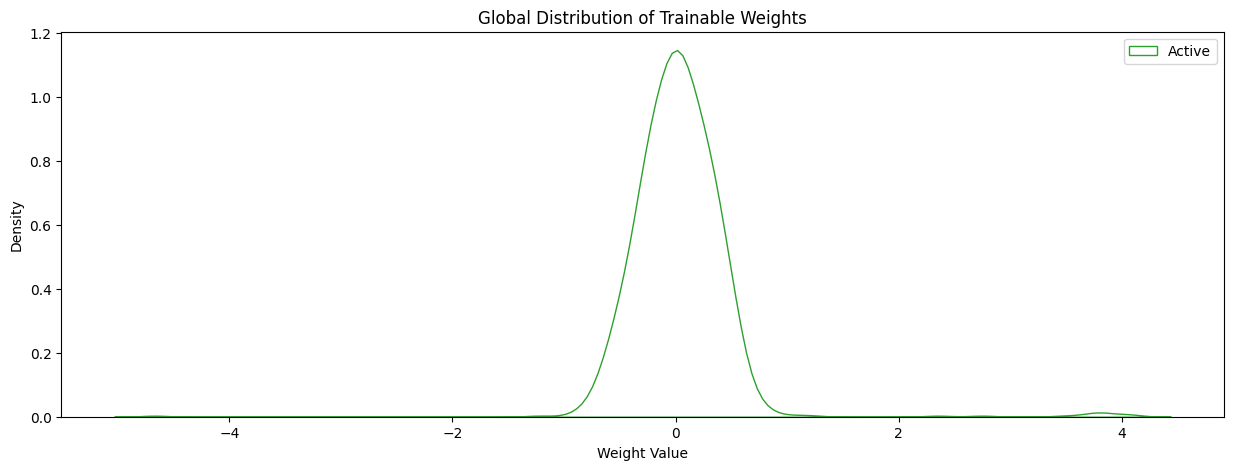

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


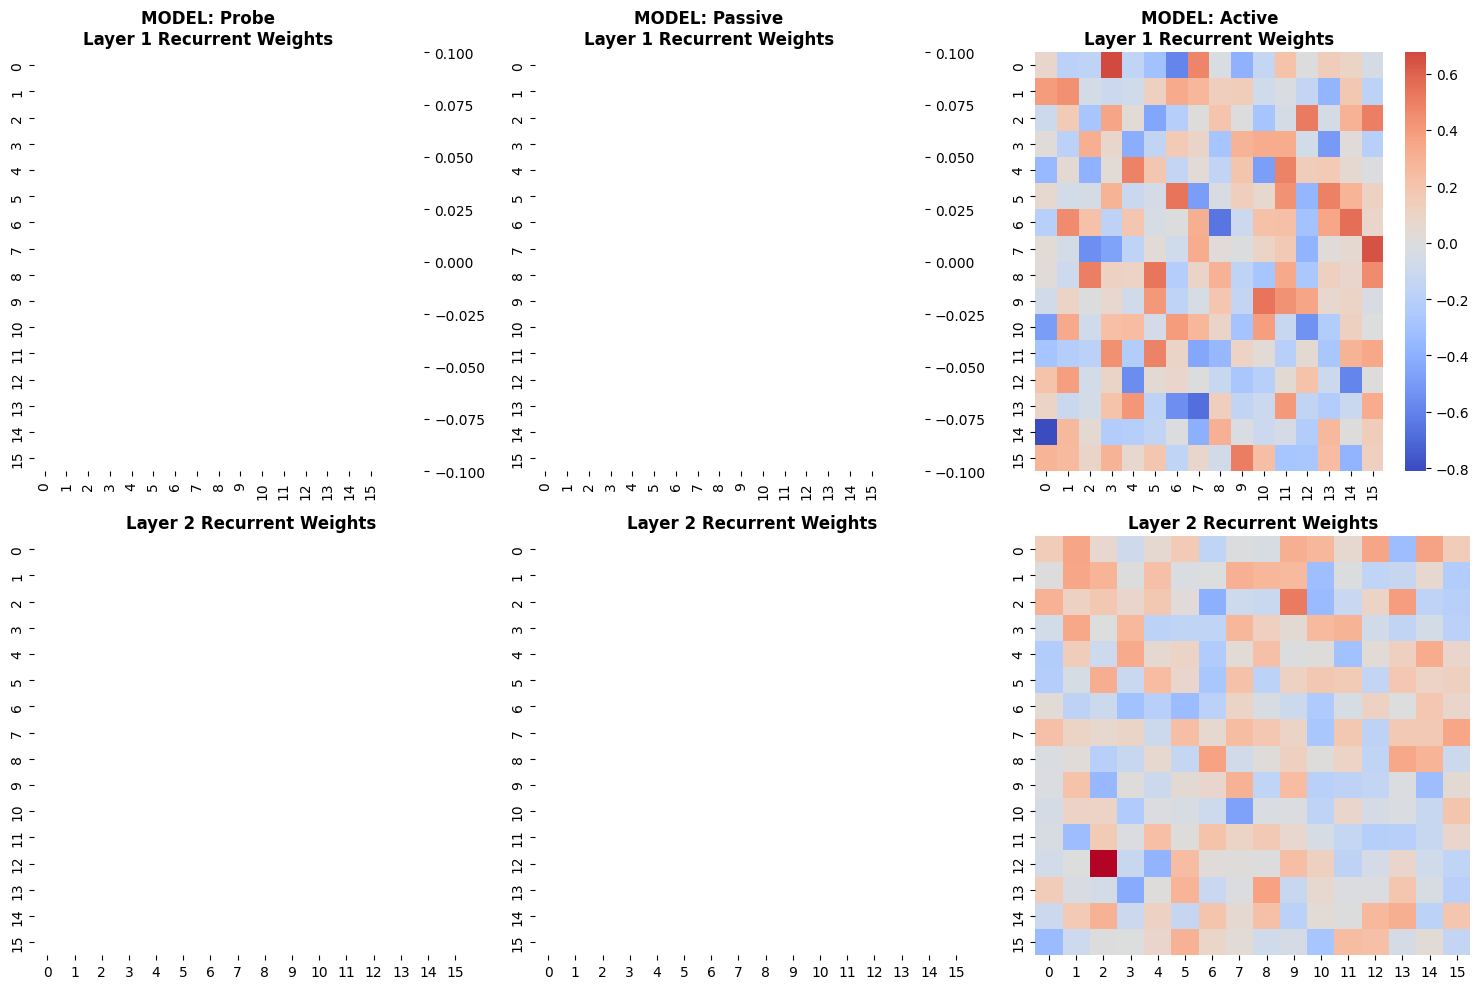

In [ ]:
import seaborn as sns

def plot_weight_distributions(models, names=['Probe', 'Passive', 'Active']):
    plt.figure(figsize=(15, 5))
    for model, name in zip(models, names):
        # Extract all trainable weights into a single flat array
        all_weights = np.concatenate([w.numpy().flatten() for w in model.trainable_variables])
        sns.kdeplot(all_weights, label=name, fill=True, alpha=0)
    
    plt.title("Global Distribution of Trainable Weights")
    plt.xlabel("Weight Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

plot_weight_distributions([model_probe, model_passive, model_active])

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_weights_comparison(models, model_names=['Probe', 'Passive', 'Active']):
    # We have 2 RNN layers per model
    num_models = len(models)
    num_layers = 2 
    
    fig, axes = plt.subplots(num_layers, num_models, figsize=(5 * num_models, 5 * num_layers))
    
    for m_idx, (model, name) in enumerate(zip(models, model_names)):
        # List the layers we want to inspect
        layers = [model.rnn1, model.rnn2]
        
        for l_idx, rnn_layer in enumerate(layers):
            # Get the recurrent weights (w_rec)
        
            w_rec = rnn_layer.cell.w_rec.numpy()
            
            ax = axes[l_idx, m_idx]
            sns.heatmap(w_rec, cmap='coolwarm', center=0, ax=ax, cbar=l_idx==0)
            
            if l_idx == 0:
                ax.set_title(f"MODEL: {name}\nLayer {l_idx+1} Recurrent Weights", fontweight='bold')
            else:
                ax.set_title(f"Layer {l_idx+1} Recurrent Weights", fontweight='bold')
                
    plt.tight_layout()
    plt.show()

# Call after training
plot_all_weights_comparison([model_probe, model_passive, model_active])



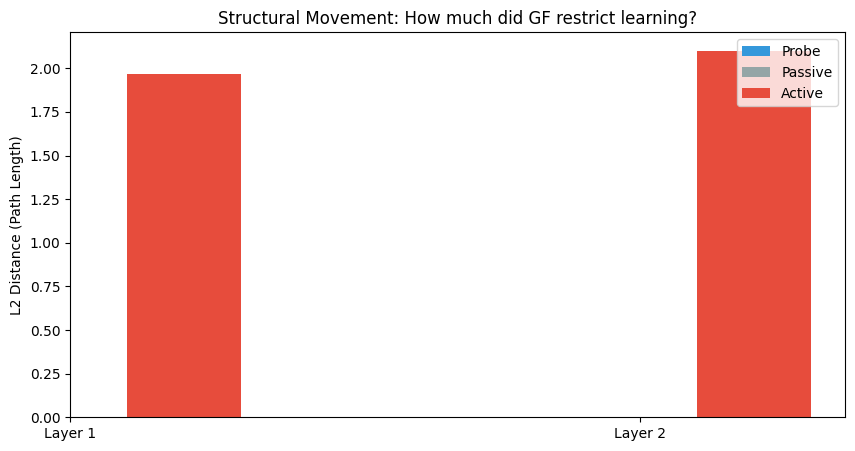

In [ ]:
def plot_drift_comparison(p, b, a):
    labels = ['Layer 1', 'Layer 2']
    x = np.arange(len(labels))
    plt.figure(figsize=(10, 5))
    plt.bar(x - 0.2, p, 0.2, label='Probe', color='#3498db')
    plt.bar(x,       b, 0.2, label='Passive', color='#95a5a6')
    plt.bar(x + 0.2, a, 0.2, label='Active', color='#e74c3c')
    plt.ylabel('L2 Distance (Path Length)')
    plt.title('Structural Movement: How much did GF restrict learning?')
    plt.xticks(x, labels)
    plt.legend()
    plt.show()

plot_drift_comparison(shift_probe, shift_passive, shift_active)